# EDA BDIFF - Jour 2

Cette analyse decrit les feux BDIFF charges dans PostgreSQL avant la modelisation. Elle couvre les volumes, la qualite, la saisonnalite, les surfaces, les causes et la repartition geographique.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text # permet d'écrire des requêtes SQL dans le code Python

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'data' / 'ingestion_pipeline')) # Ajout du chemin du pipeline d'ingestion parce que le notebook est dans le dossier analysis et non dans le dossier data/ingestion_pipeline
from config import get_engine

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Chargement et controle du perimetre

On conserve les feux non geocodes avec une jointure gauche. La vue `v_fires_geo` seule les exclurait.

In [7]:
query = text('''
    SELECT f.*, c.nom AS commune_ref, c.latitude, c.longitude,
           c.population, c.superficie_km2, c.densite, c.altitude_moy,
           c.reg_code
    FROM fires f
    LEFT JOIN ref_communes c ON c.code_insee = f.code_insee
    ORDER BY f.annee, f.numero
''')
with get_engine().connect() as conn:
    fires = pd.read_sql(query, conn)

fires['date_alerte'] = pd.to_datetime(fires['date_alerte'], errors='coerce')
fires['saison'] = fires['mois'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Ete', 7: 'Ete', 8: 'Ete',
    9: 'Automne', 10: 'Automne', 11: 'Automne',
})
print(f"{len(fires):,} feux charges".replace(',', ' '))
print(f"Periode : {fires['annee'].min()} - {fires['annee'].max()}")
fires.head()

140 246 feux charges
Periode : 1973 - 2024


,fire_id,annee,numero,departement,code_insee,nom_commune,date_alerte,mois,jour_julien,surface_parcourue_ha,surface_foret_ha,surface_maquis_ha,surface_autres_nat_ha,surface_agricole_ha,surface_autres_ha,surface_autres_boisees_ha,surface_non_boisees_nat_ha,surface_non_boisees_art_ha,precision_surfaces,type_peuplement,nature,nb_deces,nb_bat_detruits,nb_bat_partiels,precision_donnee,is_geocoded,fichier_source,commune_ref,latitude,longitude,population,superficie_km2,densite,altitude_moy,reg_code,saison
0,1973-1,1973,1,05,05169,Sorbiers,1973-07-03 05:45:00,7,184,10.0,4.700,4.80,0.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,Naturelle,NaN,NaN,NaN,NaN,True,bdiff_1973.csv,Sorbiers,44.362,5.573,50.0,14.0,3.60,904.0,93,Ete
1,1973-2,1973,2,05,05178,Ventavon,1973-08-22 16:25:00,8,234,1.0,0.470,0.48,0.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,Naturelle,NaN,NaN,NaN,NaN,True,bdiff_1973.csv,Ventavon,44.386,5.888,540.0,42.0,12.75,758.0,93,Ete
2,1973-3,1973,3,05,05078,Monêtier-Allemont,1973-08-23 14:15:00,8,235,0.5,0.235,0.24,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,True,bdiff_1973.csv,Monêtier-Allemont,44.393,5.934,302.0,8.0,40.23,724.0,93,Ete
3,1973-4,1973,4,05,05048,L'Épine,1973-08-22 15:20:00,8,234,2.0,0.940,0.96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,Naturelle,NaN,NaN,NaN,NaN,True,bdiff_1973.csv,L'Épine,44.425,5.611,200.0,34.0,5.96,1079.0,93,Ete
4,1973-5,1973,5,05,05127,Rousset,1973-09-15 20:00:00,9,258,15.0,7.050,7.20,0.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,True,bdiff_1973.csv,Rousset,44.484,6.267,167.0,17.0,10.07,944.0,93,Automne


## 2. Qualite, tendances et saisonnalite

Cette cellule produit les tableaux et graphiques necessaires (au jour 2, pour etre precis). Les feux non geocodes restent dans les statistiques nationales ; seuls les feux avec coordonnees sont utilises pour la carte.

Valeurs manquantes par colonne


,lignes_nulles,taux_nullite
nb_bat_partiels,139380,0.9938
nb_deces,139380,0.9938
nb_bat_detruits,139379,0.9938
precision_donnee,139031,0.9913
surface_autres_ha,136195,0.9711
surface_agricole_ha,136179,0.9710
surface_non_boisees_art_ha,129818,0.9256
surface_non_boisees_nat_ha,129551,0.9237
precision_surfaces,126890,0.9048
surface_autres_boisees_ha,123218,0.8786


Volumes annuels


,annee,nb_feux,surface_totale_ha,surface_mediane_ha,surface_moyenne_ha,surface_moyenne_5_ans
47,2020,2971,11225.9134,0.10,3.778497,20465.286200
48,2021,2362,12853.4992,0.10,5.441786,20746.399440
49,2022,4433,59021.3752,0.10,13.314093,18262.098380
50,2023,2682,5441.1249,0.05,2.028756,20021.144625
51,2024,1367,2768.5792,0.03,2.025296,22410.359767


Saisonnalite mensuelle


...

Surfaces par type de vegetation


,surface_totale_ha
surface_foret_ha,519350.4427
surface_maquis_ha,466169.0777
surface_autres_nat_ha,14444.0636
surface_autres_boisees_ha,13358.3669
surface_non_boisees_nat_ha,6065.7001
surface_non_boisees_art_ha,2781.4546
surface_agricole_ha,621.4500
surface_autres_ha,368.2836


Departements les plus representes


,departement,nb_feux,surface_ha
29,2B,22472,235399.6877
28,2A,18390,110298.7048
82,83,15200,142466.9395
12,13,11860,94265.9690
6,07,8956,52298.8566
5,06,8300,64467.4736
34,34,7529,48355.5150
30,30,7473,53379.5360
10,11,6100,49224.1110
66,66,5428,59649.8379


Variables candidates pour le clustering : nb de feux, surfaces, mois, jour julien, saison, densite, altitude et voisinage spatial.


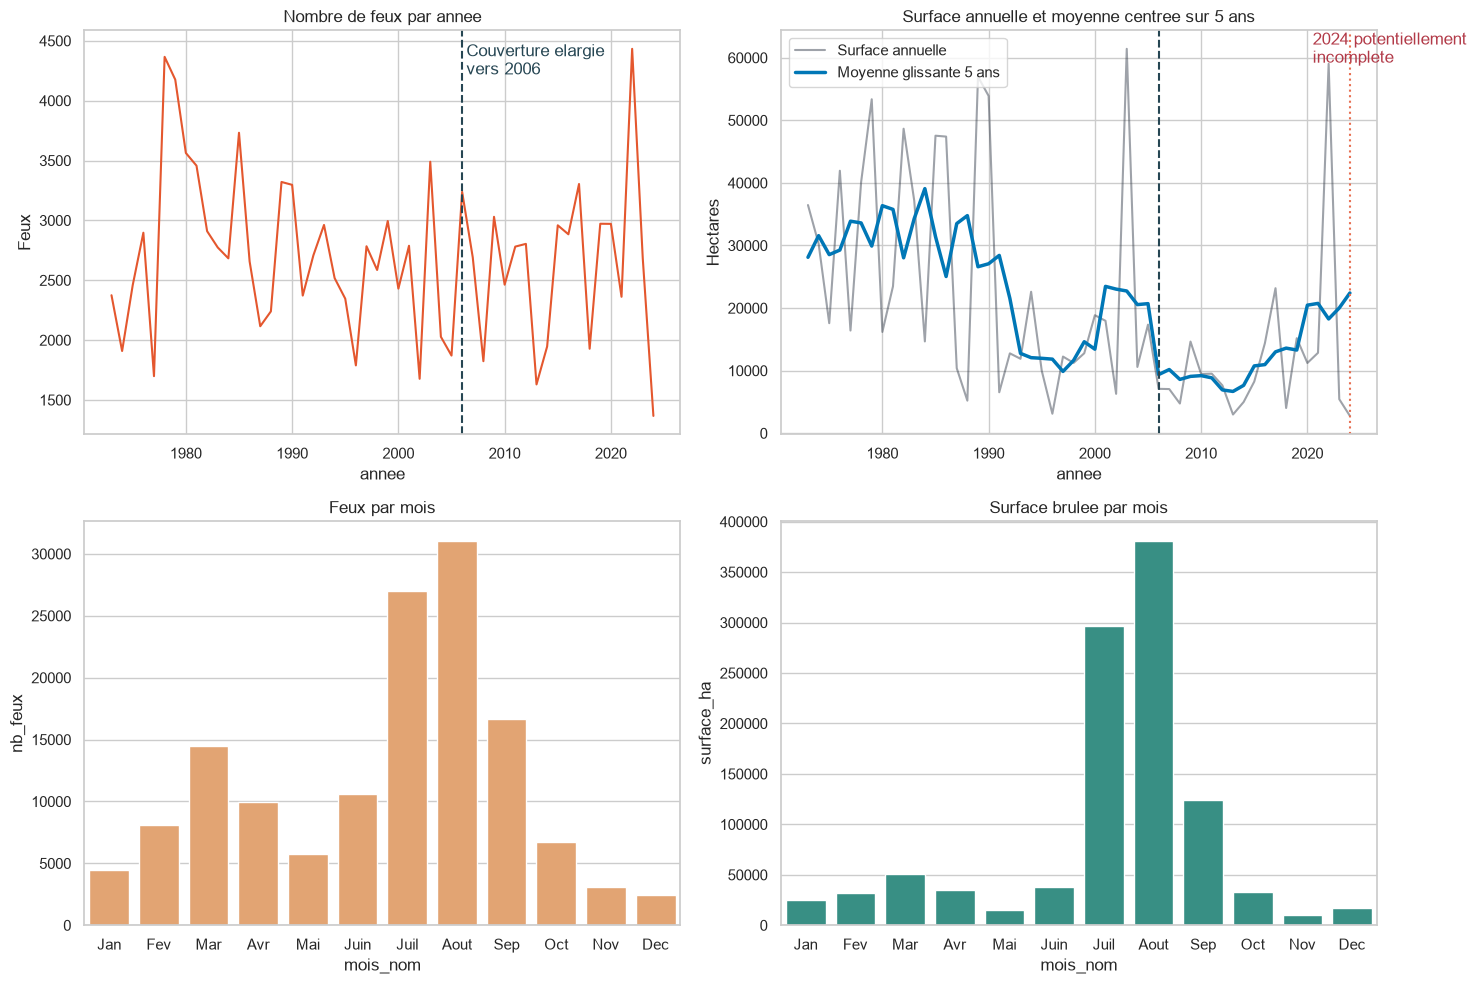

In [8]:
quality = pd.DataFrame({
    'lignes_nulles': fires.isna().sum(),
    'taux_nullite': fires.isna().mean().round(4),
}).sort_values('taux_nullite', ascending=False)
print('Valeurs manquantes par colonne')
display(quality.head(20))

annual = (
    fires.groupby('annee', as_index=False)
    .agg(
        nb_feux=('fire_id', 'count'),
        surface_totale_ha=('surface_parcourue_ha', 'sum'),
        surface_mediane_ha=('surface_parcourue_ha', 'median'),
        surface_moyenne_ha=('surface_parcourue_ha', 'mean'),
    )
)
annual['surface_moyenne_5_ans'] = annual['surface_totale_ha'].rolling(
    window=5, center=True, min_periods=1
).mean()
print('Volumes annuels')
display(annual.tail())

monthly = (
    fires.groupby('mois', as_index=False)
    .agg(nb_feux=('fire_id', 'count'), surface_ha=('surface_parcourue_ha', 'sum'))
    .set_index('mois')
    .reindex(range(1, 13))
    .fillna(0)
    .reset_index()
)
monthly['mois_nom'] = monthly['mois'].map({
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Juin',
    7: 'Juil', 8: 'Aout', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec',
})
print('Saisonnalite mensuelle')
display(monthly)

cause = (
    fires.assign(nature=fires['nature'].fillna('Non renseignee'))
    .groupby('nature', as_index=False)
    .agg(nb_feux=('fire_id', 'count'), surface_ha=('surface_parcourue_ha', 'sum'))
    .sort_values('nb_feux', ascending=False)
)
print('Repartition par nature')
display(cause)

vegetation_columns = [
    'surface_foret_ha', 'surface_maquis_ha', 'surface_autres_nat_ha',
    'surface_agricole_ha', 'surface_autres_ha', 'surface_autres_boisees_ha',
    'surface_non_boisees_nat_ha', 'surface_non_boisees_art_ha',
]
vegetation = fires[vegetation_columns].sum(min_count=1).sort_values(ascending=False)
print('Surfaces par type de vegetation')
display(vegetation.to_frame('surface_totale_ha'))

by_department = (
    fires.groupby('departement', dropna=False, as_index=False)
    .agg(nb_feux=('fire_id', 'count'), surface_ha=('surface_parcourue_ha', 'sum'))
    .sort_values('nb_feux', ascending=False)
)
print('Departements les plus representes')
display(by_department.head(15))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
annual.plot(x='annee', y='nb_feux', ax=axes[0, 0], color='#e4572e', legend=False)
axes[0, 0].axvline(2006, color='#264653', linestyle='--', linewidth=1.5)
axes[0, 0].text(2006.4, axes[0, 0].get_ylim()[1] * 0.92, 'Couverture elargie\nvers 2006', color='#264653')
axes[0, 0].set_title('Nombre de feux par annee')
axes[0, 0].set_ylabel('Feux')
annual.plot(x='annee', y='surface_totale_ha', ax=axes[0, 1], color='#293241', legend=False, alpha=0.45)
annual.plot(x='annee', y='surface_moyenne_5_ans', ax=axes[0, 1], color='#0077b6', linewidth=2.5, legend=False)
axes[0, 1].axvline(2006, color='#264653', linestyle='--', linewidth=1.5)
axes[0, 1].axvline(2024, color='#e76f51', linestyle=':', linewidth=1.5)
axes[0, 1].text(2020.5, axes[0, 1].get_ylim()[1] * 0.92, '2024 potentiellement\nincomplete', color='#b23a48')
axes[0, 1].set_title('Surface annuelle et moyenne centree sur 5 ans')
axes[0, 1].set_ylabel('Hectares')
axes[0, 1].legend(['Surface annuelle', 'Moyenne glissante 5 ans'], loc='upper left')
sns.barplot(data=monthly, x='mois_nom', y='nb_feux', color='#f4a261', ax=axes[1, 0])
axes[1, 0].set_title('Feux par mois')
sns.barplot(data=monthly, x='mois_nom', y='surface_ha', color='#2a9d8f', ax=axes[1, 1])
axes[1, 1].set_title('Surface brulee par mois')
plt.tight_layout()

print('Variables candidates pour le clustering : nb de feux, surfaces, mois, jour julien, saison, densite, altitude et voisinage spatial.')

## 4. Controle geographique

La table communale contient aussi des territoires ultramarins ou des valeurs atypiques. Pour une carte de France metropolitaine, on controle donc les bornes geographiques au lieu de tracer aveuglement toutes les coordonnees.

Coordonnees presentes : 139 280
Coordonnees plausibles en metropole : 137 929
Coordonnees hors bornes : 1 351


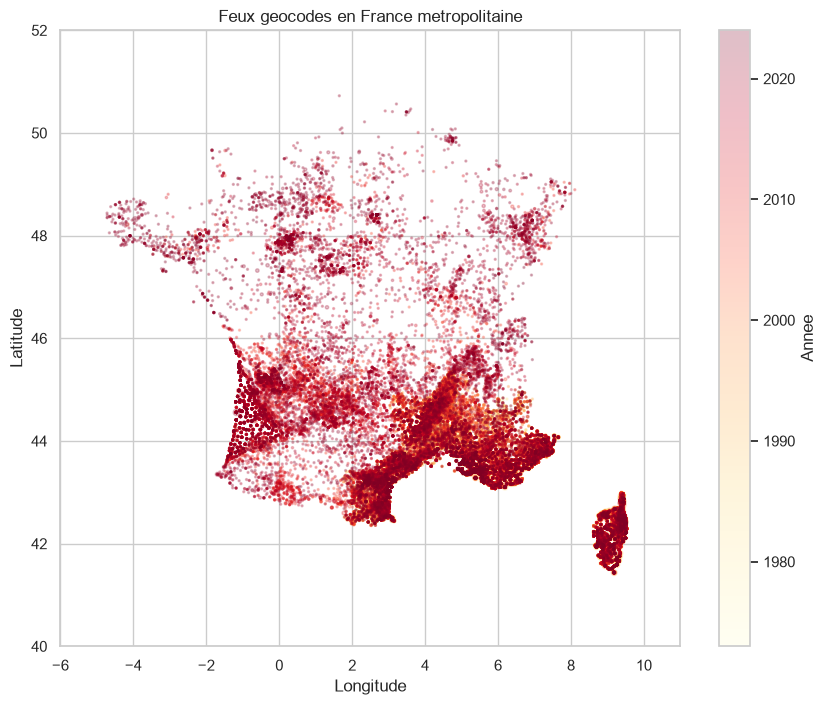

In [ ]:
geo = fires.dropna(subset=['latitude', 'longitude']).copy()
geo_metropole = geo[
    geo['latitude'].between(41.0, 51.5)
    & geo['longitude'].between(-5.5, 10.0)
].copy()
geo_metropole['taille_visuelle'] = np.clip(
    np.sqrt(geo_metropole['surface_parcourue_ha'].fillna(0)) * 2,
    4,
    70,
)
print(f"Coordonnees presentes : {len(geo):,}".replace(',', ' '))
print(f"Coordonnees plausibles en metropole : {len(geo_metropole):,}".replace(',', ' '))
print(f"Coordonnees hors bornes : {len(geo) - len(geo_metropole):,}".replace(',', ' '))

plt.figure(figsize=(10, 8))
plt.scatter(
    geo_metropole['longitude'], geo_metropole['latitude'],
    s=geo_metropole['taille_visuelle'],
    alpha=0.28, c=geo_metropole['annee'], cmap='YlOrRd', edgecolors='none',
)
plt.xlim(-6, 11)
plt.ylim(40, 52)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Feux geocodes en France metropolitaine')
plt.text(
    0.01, 0.01,
    'Taille : racine carree de la surface brulee\nCouleur : annee',
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'},
)
plt.colorbar(label='Annee')
plt.show()

## 3. Interpretation et limites

Les donnees avant 2006 ne couvrent pas toute la France. Les colonnes de vegetation changent en 2023, les causes sont souvent absentes et 2024 peut etre incomplet. Les resultats de cette EDA decrivent donc un risque historique relatif, pas une probabilite causale ni une prevision operationnelle.

La tendance glissante sur cinq ans et la saisonnalite mensuelle sont retenues plutot que STL : elles sont suffisantes pour le jour 2 et plus simples a expliquer.